In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F
import torch.nn as nn
from tqdm import tqdm
import yfinance as yf
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, accuracy_score, f1_score, r2_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.feature_selection import RFECV
import warnings

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Reading files

In [2]:
DAILY_DIRECTORY = Path("daily")

shape: (6, 2)
┌───────────────────────┬────────┐
│ source                ┆ len    │
│ ---                   ┆ ---    │
│ str                   ┆ u32    │
╞═══════════════════════╪════════╡
│ yahoo.com             ┆ 582763 │
│ reuters.com           ┆ 475871 │
│ bloomberg.com         ┆ 87256  │
│ cnbc.com              ┆ 76054  │
│ thomsonreuters.com    ┆ 504    │
│ thomsonreuters.com.au ┆ 16     │
└───────────────────────┴────────┘


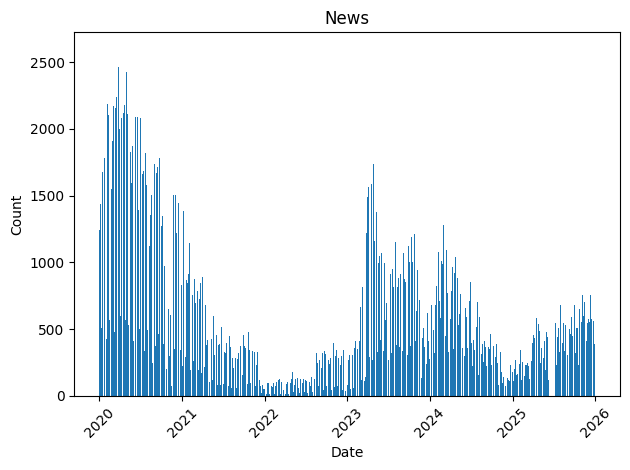

In [3]:
files = DAILY_DIRECTORY.glob("*.parquet")
df = pl.scan_parquet(files)

fin_df = (
    df
    .filter(
        pl.any_horizontal(
            pl.col("source").str.contains("cnbc.com|reuters.com|(?:^|\\.)bloomberg.com"),
            (pl.col("url").str.contains("finance\\.yahoo") & pl.col("source").str.contains("yahoo.com"))
        )
    )
    .with_columns(
        pl.col("datetime").dt.date().alias("date")
    )
)

daily_counts = (
    fin_df
    .group_by("date")
    .len()
    .sort("date")
)

result = daily_counts.collect(engine="streaming")

print(fin_df.group_by("source").len().sort(by="len", descending=True).collect(engine="streaming"))

plt.bar(result["date"], result["len"])
plt.title("News")
plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

shape: (6, 2)
┌───────────────────────┬───────┐
│ source                ┆ len   │
│ ---                   ┆ ---   │
│ str                   ┆ u32   │
╞═══════════════════════╪═══════╡
│ reuters.com           ┆ 21000 │
│ yahoo.com             ┆ 15343 │
│ bloomberg.com         ┆ 1336  │
│ cnbc.com              ┆ 1151  │
│ thomsonreuters.com    ┆ 3     │
│ thomsonreuters.com.au ┆ 1     │
└───────────────────────┴───────┘


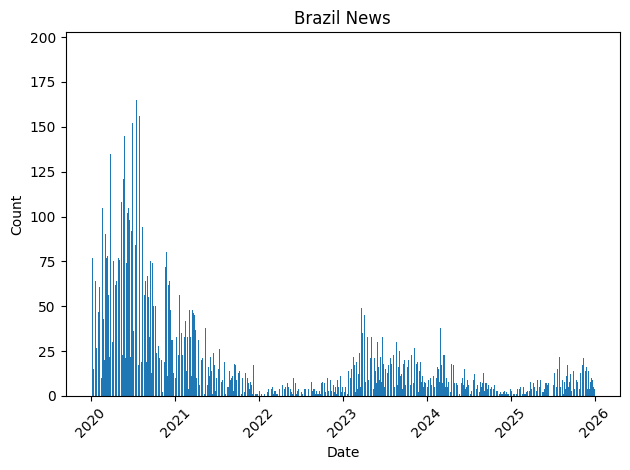

In [4]:
FILTERED_BRAZIL_PATH = Path("brazil_news")
FILTERED_BRAZIL_PATH.mkdir(exist_ok=True)

if not (FILTERED_BRAZIL_PATH / "brazil.parquet").exists():
    brazil_news = (
        fin_df
        .filter(
            pl.any_horizontal(
                pl.col("locations", "url", "themes", "v2themes", "title").str.contains_any(["brazil"], ascii_case_insensitive=True)
            )
        )
        .drop("date")
        .drop_nulls("title")
        .collect(engine="streaming")
    )

    brazil_news.write_parquet(FILTERED_BRAZIL_PATH / "brazil.parquet")

brazil_news = pl.read_parquet(FILTERED_BRAZIL_PATH / "brazil.parquet")

brazil_counts = (
    brazil_news
    .with_columns(
        pl.col("datetime").dt.date().alias("date")
    )
    .group_by("date")
    .len()
)

print(brazil_news.group_by("source").len().sort(by="len", descending=True))

plt.bar(brazil_counts["date"], brazil_counts["len"])
plt.title("Brazil News")
plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Modeling

## Use finBERT to extract sentiment from title column

In [5]:
MODEL = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)
device = torch.device("cpu")
model.to(device)
model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [6]:
labels = ("negative", "neutral", "positive")

In [7]:
def predict_sentiment(texts: list[str], batch_size=32):

    results: list[dict[str, float]] = []

    for i in range(0, len(texts), batch_size):

        batch = texts[i:i+batch_size]

        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)

        probs = F.softmax(outputs.logits, dim=1).cpu()

        for p in probs:
            results.append({
                "negative": p[0],
                "neutral": p[1],
                "positive": p[2],
                "sentiment_score": p[2] - p[0]
            })

    return results

In [8]:
if not "sentiment_score" in brazil_news.columns:

    titles = brazil_news["title"].to_list()

    sentiments = []

    BATCH_SIZE = 2048

    for i in tqdm(range(0, len(titles), BATCH_SIZE)):
        batch = titles[i:i+BATCH_SIZE]
        sentiments.extend(predict_sentiment(batch))
    
    sentiment_df = pl.DataFrame(sentiments)

    brazil_news = brazil_news.with_columns(sentiment_df)
    brazil_news.write_parquet(FILTERED_BRAZIL_PATH /  "brazil.parquet")

brazil_news = pl.read_parquet(FILTERED_BRAZIL_PATH /  "brazil.parquet")

## Download IBOVESPA from 2020 until 2025

In [9]:
ibov = pl.from_pandas(yf.download("^BVSP", start="2020-01-01", end="2026-01-01", progress=False, multi_level_index=False).reset_index())
ibov = ibov.rename({col:col.lower() for col in ibov.columns})

ibov = ibov.with_columns([
    pl.col("date").cast(pl.Date),
])

## Feature Engineering

In [ ]:
# Aggregate Brazil news daily

daily_news = (
    brazil_news.with_columns(pl.col("datetime").dt.date().alias("date"))
    .group_by("date")
    .agg([
        pl.len().alias("news_volume"),
        pl.col("sentiment_score").mean().alias("sentiment_mean"),
        # pl.col("positive").mean().alias("positive_mean"),
        # pl.col("negative").mean().alias("negative_mean"),
        pl.col("tone").mean().alias("tone"),
    ])
    .with_columns(
        (pl.col("positive_mean") - pl.col("negative_mean")).alias("sentiment_imbalance"),
    )
    .sort("date")
)

# Keep only a small, interpretable feature set for easier testing.
# No-news trading days are filled with neutral news values instead of being dropped.

news_cols = [
    "news_volume",
    "sentiment_mean",
    "positive_mean",
    "negative_mean",
    "tone",
    "sentiment_imbalance",
]

required_model_cols = [
    "return",
    "target_return",
    "target_direction",
    "momentum_5d",
    "volatility_5d",
    "trend_20d",
    "drawdown_20d",
]

dataset = (
    ibov
    .join(daily_news, on="date", how="left")
    .sort("date")
    .with_columns([
        pl.col("news_volume").fill_null(0),
        pl.col("sentiment_mean").fill_null(0),
        pl.col("positive_mean").fill_null(0),
        pl.col("negative_mean").fill_null(0),
        pl.col("tone").fill_null(0),
        pl.col("sentiment_imbalance").fill_null(0),
    ])
    .with_columns([
        (pl.col("close") / pl.col("close").shift(1) - 1).alias("return"),
        (pl.col("news_volume") + 1).log().alias("log_news_volume"),
    ])
    .with_columns([
        pl.col("return").shift(-1).alias("target_return"),
        (pl.col("return").shift(-1) > 0).cast(pl.Int8).alias("target_direction"),
        pl.col("return").rolling_mean(5).alias("momentum_5d"),
        pl.col("return").rolling_std(5).alias("volatility_5d"),
        (pl.col("close") / pl.col("close").rolling_mean(20) - 1).alias("trend_20d"),
        (pl.col("close") / pl.col("close").rolling_max(20) - 1).alias("drawdown_20d"),
    ])
)

# Shift news features one trading day to avoid using same-day information.
lagged_news_cols = news_cols + ["log_news_volume"]

pdf = (
    dataset
    .with_columns([pl.col(c).shift(1) for c in lagged_news_cols])
    .drop_nulls(subset=required_model_cols)
    .to_pandas()
)


### Select features for training and prediction

In [11]:
sentiment_features = [
    "sentiment_mean",
    "sentiment_imbalance",
    "log_news_volume",
]

gdelt_tone_features = [
    "tone",
]

price_features = [
    "return",
    "momentum_5d",
    "volatility_5d",
    "trend_20d",
    "drawdown_20d",
]


### Create functions to run the classification and regression

In [12]:
tscv = TimeSeriesSplit(n_splits=5)


def scale_train_test(X_train, X_test):
    scaler = StandardScaler()
    return (
        pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index),
        pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index),
    )


class TabularMLP(nn.Module):
    def __init__(self, n_features, hidden_size=16, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


class MLPModel:
    def __init__(self, task, hidden_size=16, dropout=0.2, lr=1e-3, weight_decay=1e-4, epochs=100, patience=10, random_state=42):
        self.task = task
        self.hidden_size = hidden_size
        self.dropout = dropout
        self.lr = lr
        self.weight_decay = weight_decay
        self.epochs = epochs
        self.patience = patience
        self.random_state = random_state

    def fit(self, X, y):
        torch.manual_seed(self.random_state)
        self.model_ = TabularMLP(X.shape[1], self.hidden_size, self.dropout)
        optimizer = torch.optim.AdamW(self.model_.parameters(), lr=self.lr, weight_decay=self.weight_decay)
        criterion = nn.BCEWithLogitsLoss() if self.task == "classification" else nn.MSELoss()

        X_tensor = torch.tensor(X.to_numpy(), dtype=torch.float32)
        y_tensor = torch.tensor(np.asarray(y), dtype=torch.float32)
        split_idx = max(1, int(len(X_tensor) * 0.8))
        X_train, X_val = X_tensor[:split_idx], X_tensor[split_idx:]
        y_train, y_val = y_tensor[:split_idx], y_tensor[split_idx:]

        best_loss = float("inf")
        best_state = None
        wait = 0

        for _ in range(self.epochs):
            self.model_.train()
            optimizer.zero_grad()
            loss = criterion(self.model_(X_train), y_train)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model_.parameters(), max_norm=1.0)
            optimizer.step()

            self.model_.eval()
            with torch.no_grad():
                val_loss = criterion(self.model_(X_val), y_val).item() if len(X_val) else loss.item()

            if val_loss < best_loss:
                best_loss = val_loss
                best_state = {k: v.detach().clone() for k, v in self.model_.state_dict().items()}
                wait = 0
            else:
                wait += 1
                if wait >= self.patience:
                    break

        if best_state is not None:
            self.model_.load_state_dict(best_state)
        return self

    def _predict_raw(self, X):
        self.model_.eval()
        with torch.no_grad():
            X_tensor = torch.tensor(X.to_numpy(), dtype=torch.float32)
            return self.model_(X_tensor).numpy()

    def predict(self, X):
        raw = self._predict_raw(X)
        if self.task == "classification":
            return (1 / (1 + np.exp(-raw)) >= 0.5).astype(int)
        return raw

    def predict_proba(self, X):
        raw = self._predict_raw(X)
        proba = 1 / (1 + np.exp(-raw))
        return np.column_stack([1 - proba, proba])


def make_classifiers(include_mlp=True):
    models = {
        "log_reg": LogisticRegression(max_iter=2000),
        "rf_clas": RandomForestClassifier(
            n_estimators=500,
            max_depth=6,
            random_state=42,
            n_jobs=-1,
        ),
        "xgb_clas": XGBClassifier(
            n_estimators=400,
            max_depth=4,
            learning_rate=0.03,
            subsample=0.8,
            colsample_bytree=0.8,
        ),
    }
    if include_mlp:
        models["mlp_clas"] = MLPModel(task="classification")
    return models


def make_regressors(include_mlp=True):
    models = {
        "lin_reg": LinearRegression(n_jobs=-1),
        "rf_reg": RandomForestRegressor(
            n_estimators=500,
            max_depth=6,
            random_state=42,
            n_jobs=-1,
        ),
        "xgb_reg": XGBRegressor(
            n_estimators=400,
            max_depth=4,
            learning_rate=0.03,
        ),
    }
    if include_mlp:
        models["mlp_reg"] = MLPModel(task="regression")
    return models


def summarize_metrics(fold_metrics):
    fold_df = pd.DataFrame(fold_metrics)
    return {
        f"{metric}_{stat}": getattr(fold_df[metric], stat)()
        for metric in fold_df.columns
        for stat in ("mean", "std")
    }


def run_classification(model, X, y):
    fold_metrics = []
    y_true, y_pred, all_proba = [], [], []

    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        X_train, X_test = scale_train_test(X_train, X_test)

        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        proba = model.predict_proba(X_test)[:, 1]

        fold_metrics.append({
            "accuracy": accuracy_score(y_test, pred),
            "f1": f1_score(y_test, pred),
            "roc_auc": roc_auc_score(y_test, proba),
        })
        y_true.append(y_test)
        y_pred.append(pred)
        all_proba.append(proba)

    return (
        summarize_metrics(fold_metrics),
        pd.concat(y_true),
        np.concatenate(y_pred),
        np.concatenate(all_proba),
    )


def run_regression(model, X, y):
    fold_metrics = []
    y_true, y_pred = [], []

    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        X_train, X_test = scale_train_test(X_train, X_test)

        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        fold_metrics.append({
            "rmse": root_mean_squared_error(y_test, pred),
            "mae": mean_absolute_error(y_test, pred),
            "r2": r2_score(y_test, pred),
        })
        y_true.append(y_test)
        y_pred.append(pred)

    return summarize_metrics(fold_metrics), pd.concat(y_true), np.concatenate(y_pred)


CLASSIFIERS = make_classifiers()
REGRESSORS = make_regressors()


def evaluate_models(X, y_cls, y_reg, classifiers=None, regressors=None):
    classifiers = classifiers or make_classifiers()
    regressors = regressors or make_regressors()

    clf_results = []
    reg_results = []
    clf_importance = {}
    reg_importance = {}

    for name, model in classifiers.items():
        metrics, *_ = run_classification(model, X, y_cls)
        clf_results.append({"model": name, **metrics})
        if hasattr(model, "feature_importances_"):
            clf_importance[name] = pd.Series(model.feature_importances_, index=X.columns)

    for name, model in regressors.items():
        metrics, *_ = run_regression(model, X, y_reg)
        reg_results.append({"model": name, **metrics})
        if hasattr(model, "feature_importances_"):
            reg_importance[name] = pd.Series(model.feature_importances_, index=X.columns)

    return (
        pd.DataFrame(clf_results).sort_values("accuracy_mean", ascending=False),
        pd.DataFrame(reg_results).sort_values("r2_mean", ascending=False),
        clf_importance,
        reg_importance,
    )


def plot_metric_bars(ax, df, metric_cols, title):
    x = np.arange(len(df))
    width = 0.8 / len(metric_cols)

    for i, col in enumerate(metric_cols):
        ax.bar(x + (i - (len(metric_cols) - 1) / 2) * width, df[col], width, label=col)

    ax.set_xticks(x, df["model"])
    ax.set_xlabel("Model")
    ax.set_ylabel("Score")
    ax.set_title(title)
    ax.legend(title="Metric")
    ax.grid()


def plot_importance(ax, importance, title, top_n=15):
    if importance:
        pd.concat(importance, axis=1).fillna(0).mean(axis=1).sort_values(ascending=False).head(top_n).plot.bar(ax=ax)
    ax.set_title(title)
    ax.grid()


def plot_model_results(feature_cols, title):
    X = pdf[feature_cols]
    clf_df, reg_df, clf_importance, reg_importance = evaluate_models(X, y_dir, y_ret)

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle(title)
    plot_metric_bars(axes[0, 0], clf_df, ["accuracy_mean", "f1_mean", "roc_auc_mean"], "Classifier Performance")
    plot_metric_bars(axes[0, 1], reg_df, ["rmse_mean", "r2_mean", "mae_mean"], "Regressor Performance")
    plot_importance(axes[1, 0], clf_importance, "Feature Importance - Tree Classifiers")
    plot_importance(axes[1, 1], reg_importance, "Feature Importance - Tree Regressors")
    plt.tight_layout()
    plt.show()

    return clf_df, reg_df, clf_importance, reg_importance


def evaluate_rfecv_models(X, y_cls, y_reg):
    classifiers = make_classifiers(include_mlp=False)
    regressors = make_regressors(include_mlp=False)
    clf_results, reg_results = [], []
    clf_curves, reg_curves = {}, {}
    clf_importance, reg_importance = {}, {}

    for name, model in classifiers.items():
        selector = run_rfecv(model, X, y_cls, scoring="accuracy")
        best_features = X.columns[selector.support_].tolist()
        clf_curves[name] = selector.cv_results_["mean_test_score"]
        model.fit(X[best_features], y_cls)
        clf_importance[name] = get_feature_importance(model, best_features)
        metrics, *_ = run_classification(model, X[best_features], y_cls)
        clf_results.append({"model": name, "features": best_features, **metrics})

    for name, model in regressors.items():
        selector = run_rfecv(model, X, y_reg, scoring="neg_mean_squared_error")
        best_features = X.columns[selector.support_].tolist()
        reg_curves[name] = selector.cv_results_["mean_test_score"]
        model.fit(X[best_features], y_reg)
        reg_importance[name] = get_feature_importance(model, best_features)
        metrics, *_ = run_regression(model, X[best_features], y_reg)
        reg_results.append({"model": name, "features": best_features, **metrics})

    return (
        pd.DataFrame(clf_results).sort_values("accuracy_mean", ascending=False),
        pd.DataFrame(reg_results).sort_values("r2_mean", ascending=False),
        clf_curves,
        reg_curves,
        clf_importance,
        reg_importance,
    )


def plot_rfecv_curves(ax, curves, title, ylabel):
    for name, scores in curves.items():
        ax.plot(range(1, len(scores) + 1), scores, label=name)
    ax.set_title(title)
    ax.set_xlabel("Number of Selected Features")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid()


def plot_importance_heatmap(ax, importance, title):
    imp_df = pd.DataFrame(importance).fillna(0)
    imp_df = imp_df.div(imp_df.max().replace(0, np.nan), axis=1).fillna(0)

    image = ax.imshow(imp_df.values, aspect="auto")
    ax.set_yticks(range(len(imp_df.index)), imp_df.index)
    ax.set_xticks(range(len(imp_df.columns)), imp_df.columns)
    ax.set_title(title)
    ax.set_xlabel("Model")
    ax.set_ylabel("Feature")
    plt.colorbar(image, ax=ax, label="Normalized Importance")


def plot_rfecv_results(feature_cols, title):
    results = evaluate_rfecv_models(pdf[feature_cols], y_dir, y_ret)
    clf_df, reg_df, clf_curves, reg_curves, clf_importance, reg_importance = results

    fig, axes = plt.subplots(3, 2, figsize=(15, 20))
    fig.suptitle(title)
    plot_metric_bars(axes[0, 0], clf_df, ["accuracy_mean", "f1_mean", "roc_auc_mean"], "Classifier Performance")
    plot_rfecv_curves(axes[0, 1], clf_curves, "RFECV Curves - Classifiers", "Cross-Validated Accuracy")
    plot_metric_bars(axes[1, 0], reg_df, ["rmse_mean", "r2_mean", "mae_mean"], "Regressor Performance")
    plot_rfecv_curves(axes[1, 1], reg_curves, "RFECV Curves - Regressors", "Cross-Validated Score (neg MSE)")
    plot_importance_heatmap(axes[2, 0], clf_importance, "Feature Importance Heatmap - Classifiers")
    plot_importance_heatmap(axes[2, 1], reg_importance, "Feature Importance Heatmap - Regressors")
    plt.tight_layout()
    plt.show()

    return results


## Evaluating models with all features

In [13]:
y_dir = pdf["target_direction"]
y_ret = pdf["target_return"]

### Testing only return

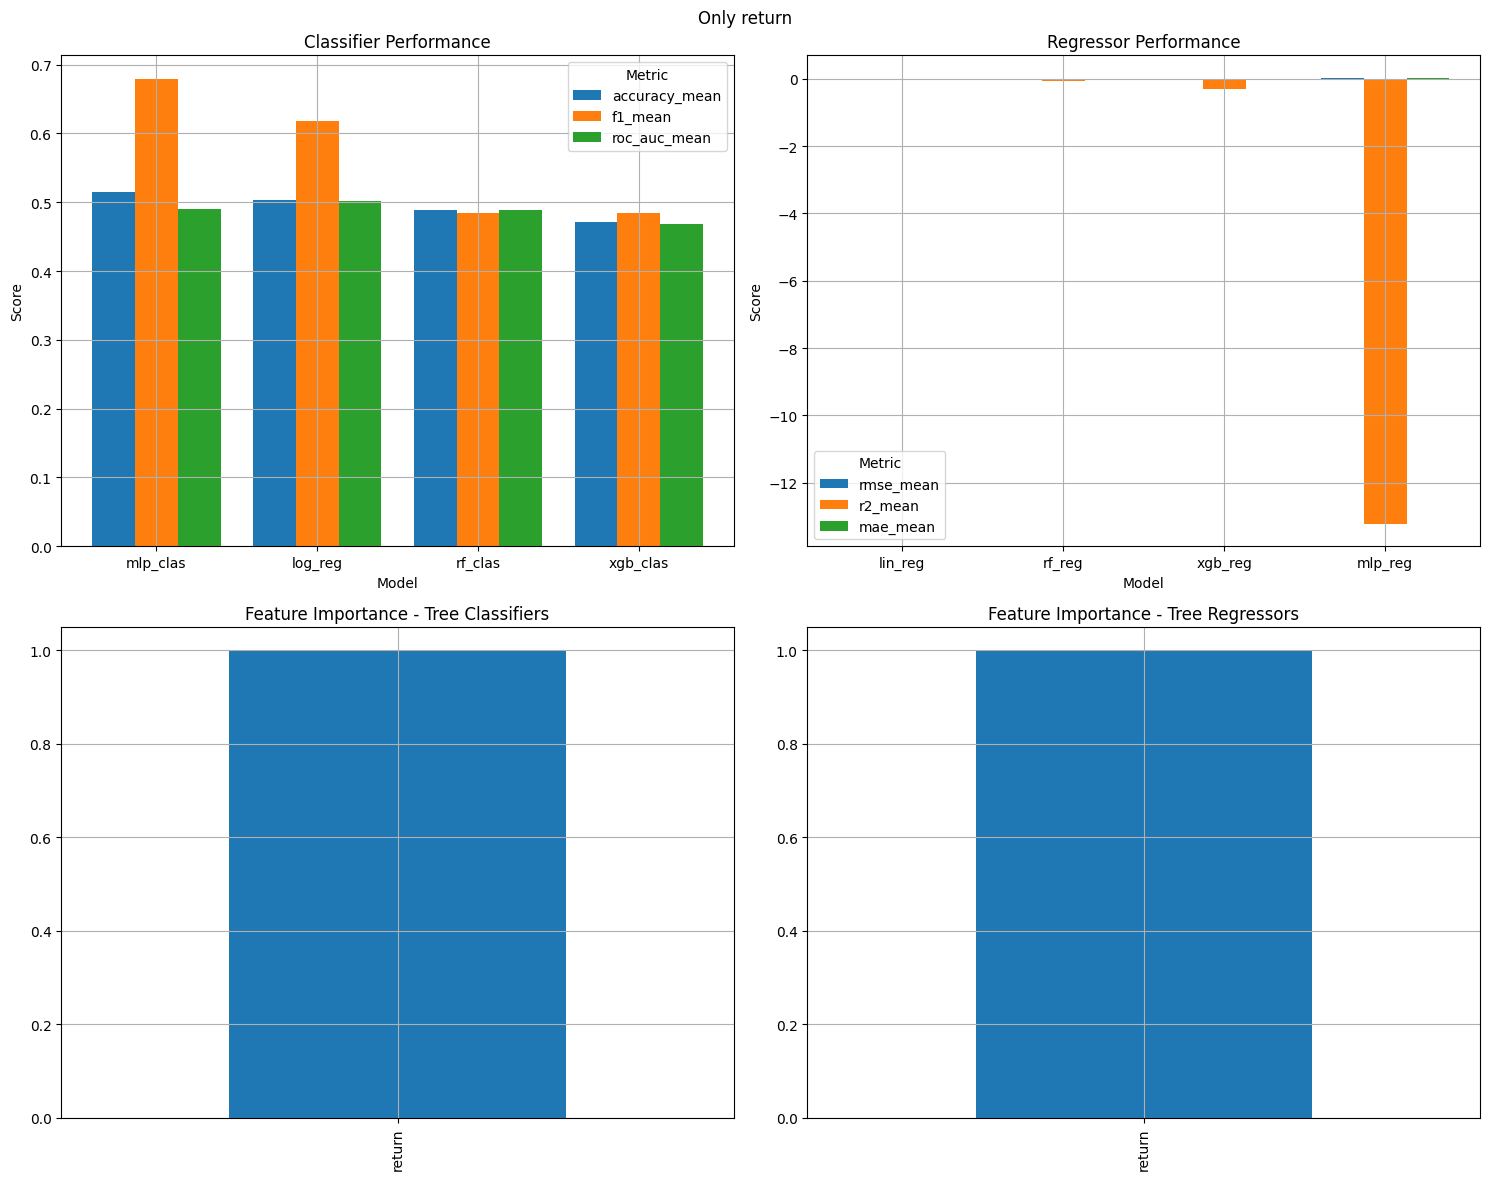

In [14]:
return_results = plot_model_results(["return"], "Only return")

### Testing only sentiment score

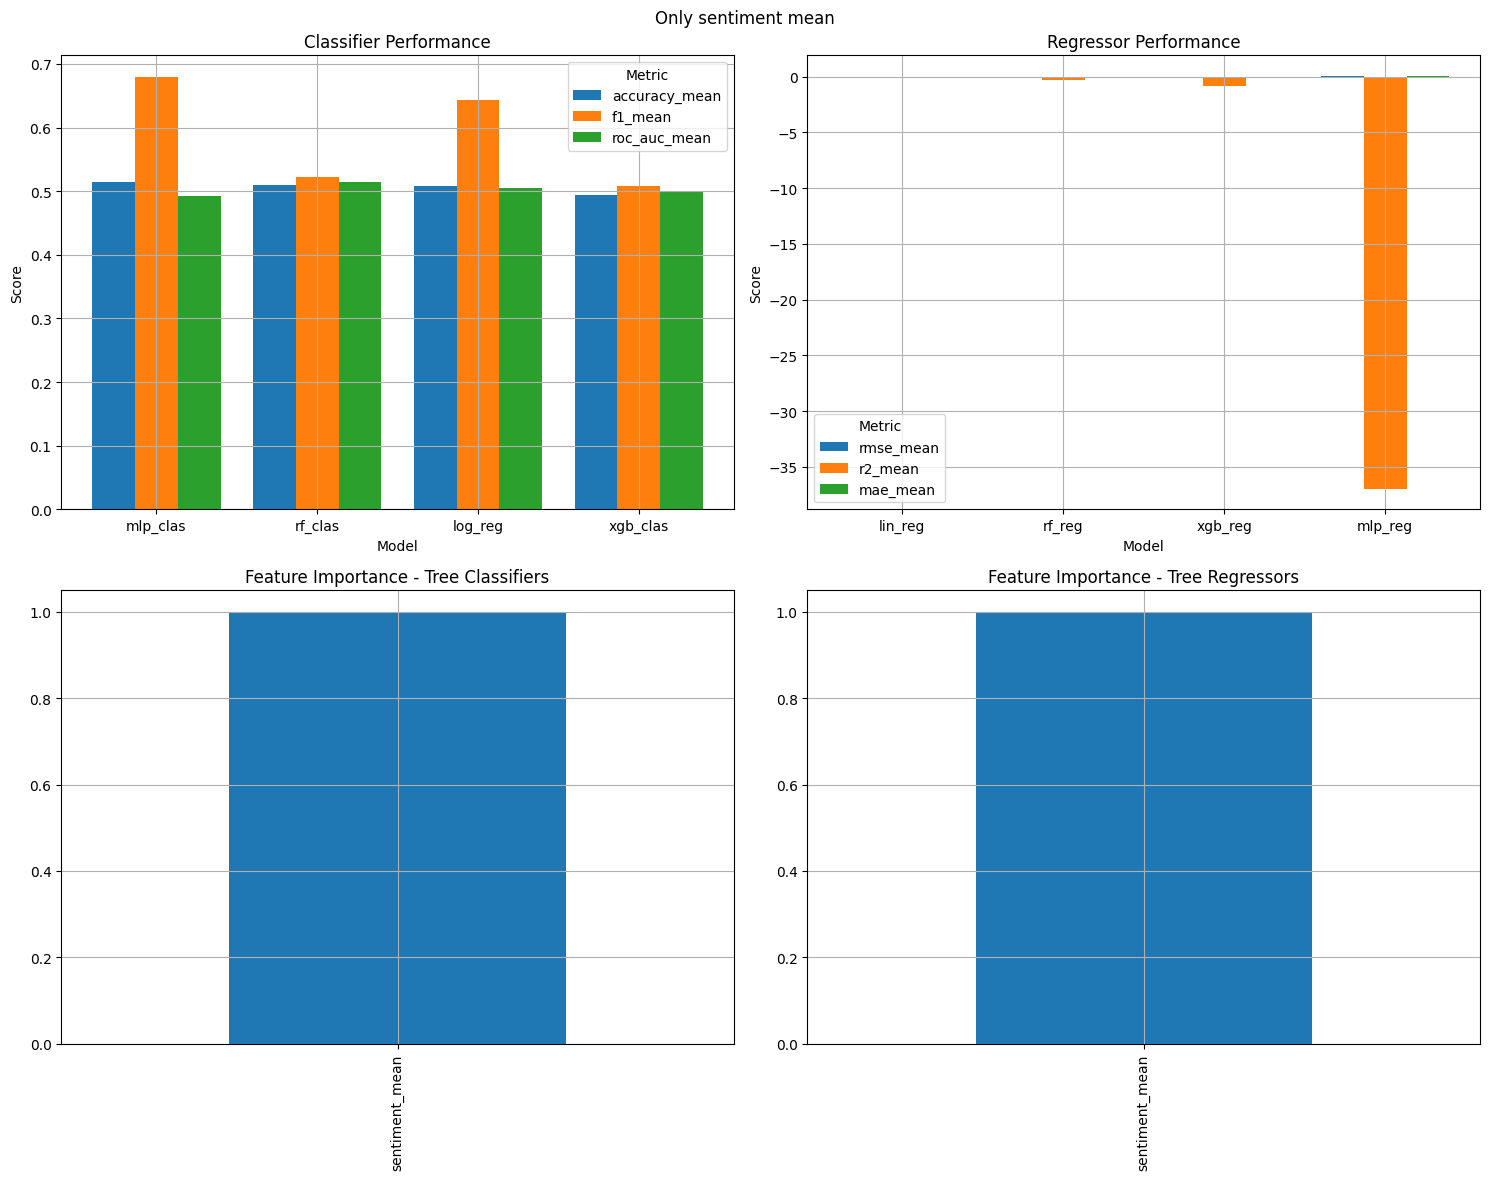

In [15]:
sentiment_mean_results = plot_model_results(["sentiment_mean"], "Only sentiment mean")

### Testing only tone

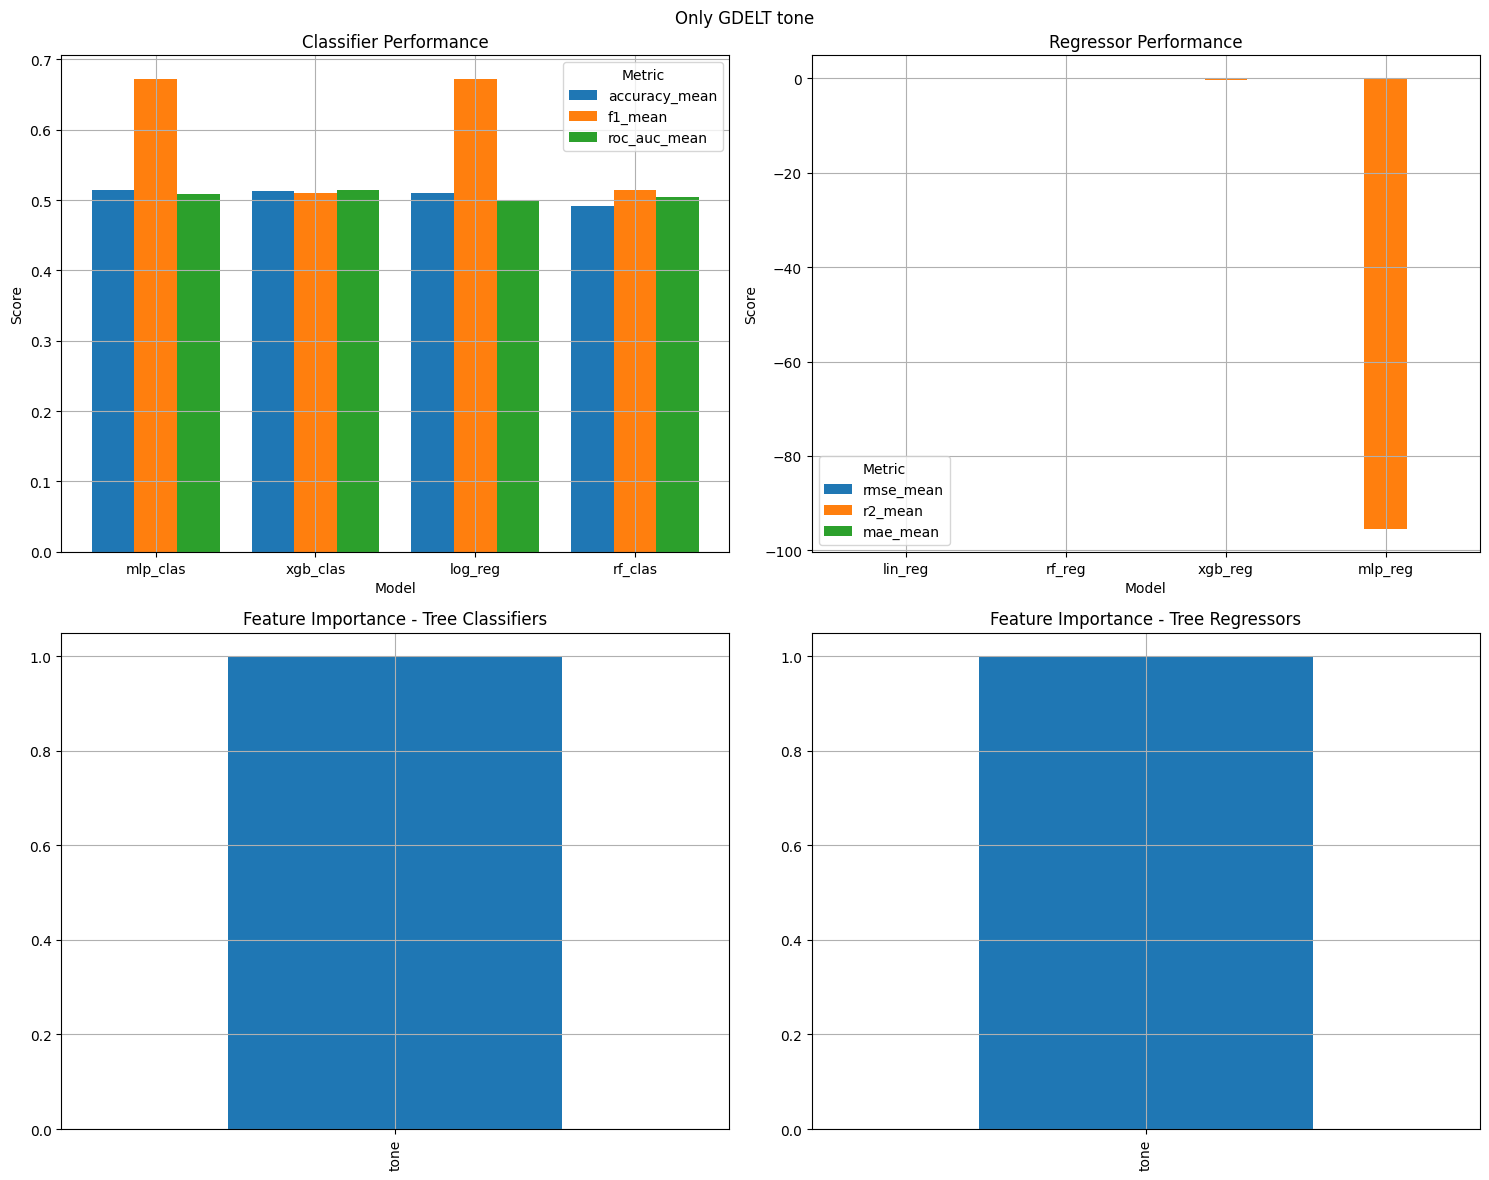

In [16]:
tone_results = plot_model_results(gdelt_tone_features, "Only GDELT tone")


### Testing all sentiment related features

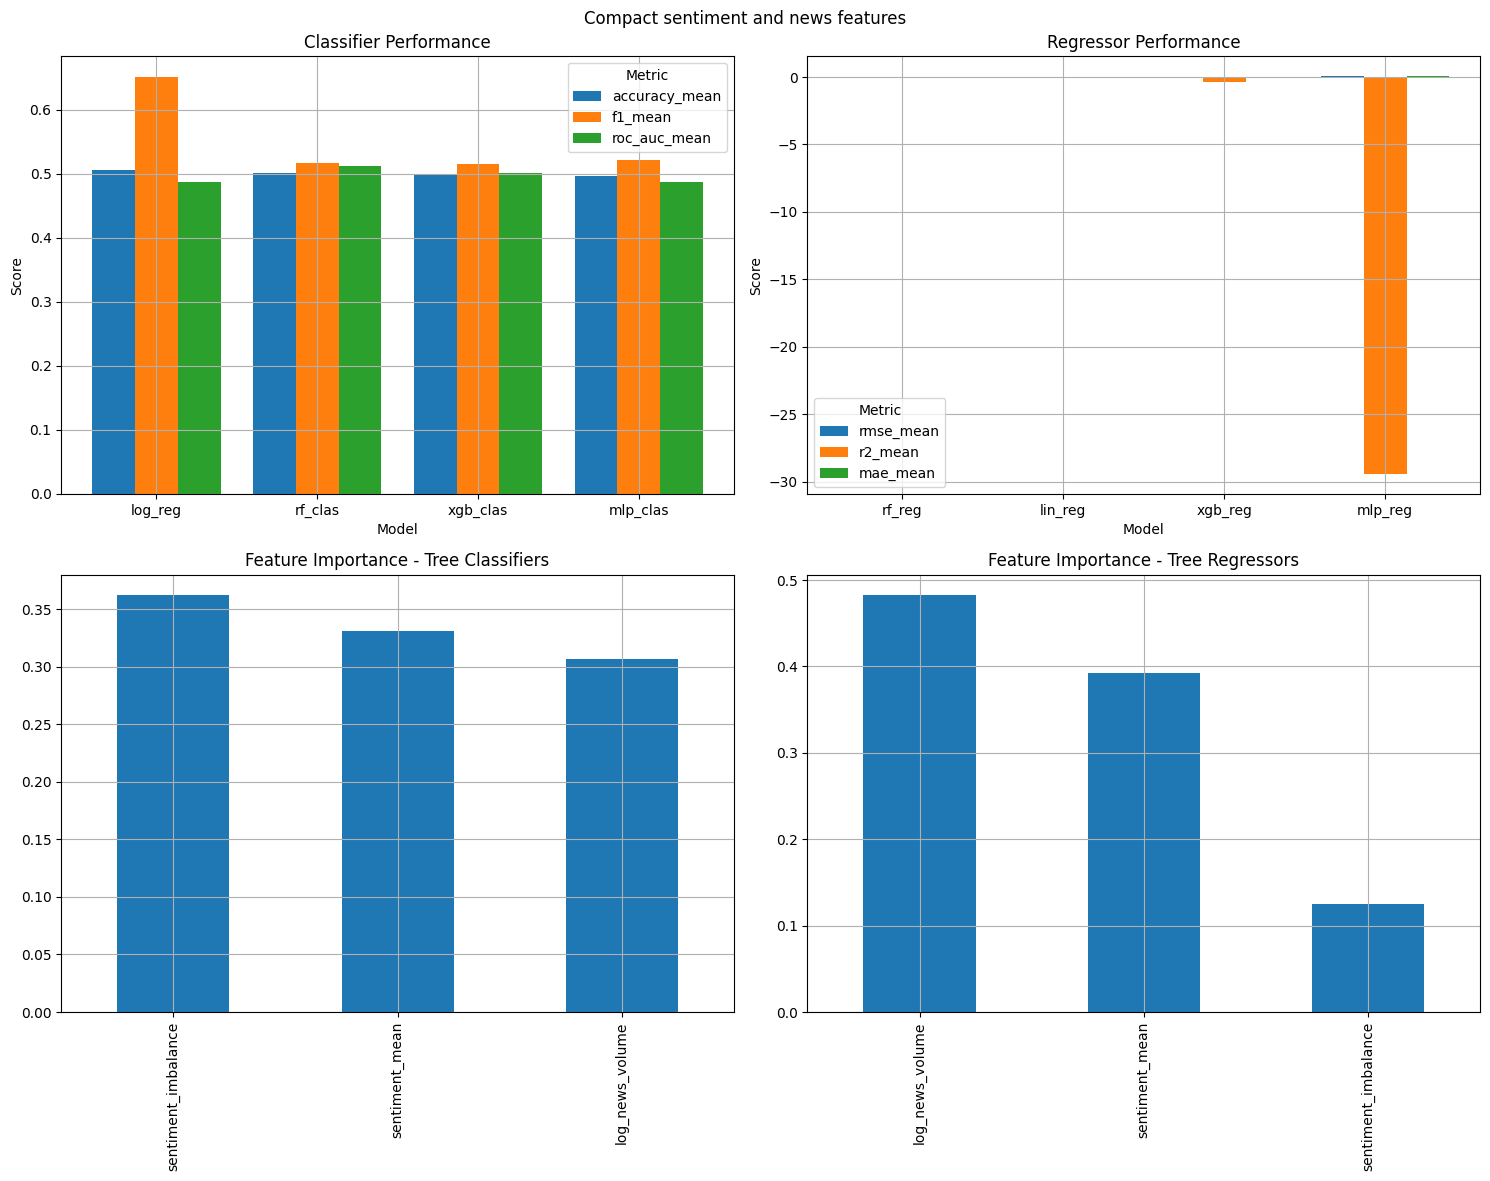

In [17]:
sentiment_results = plot_model_results(sentiment_features, "Compact sentiment and news features")


### Testing all price related features

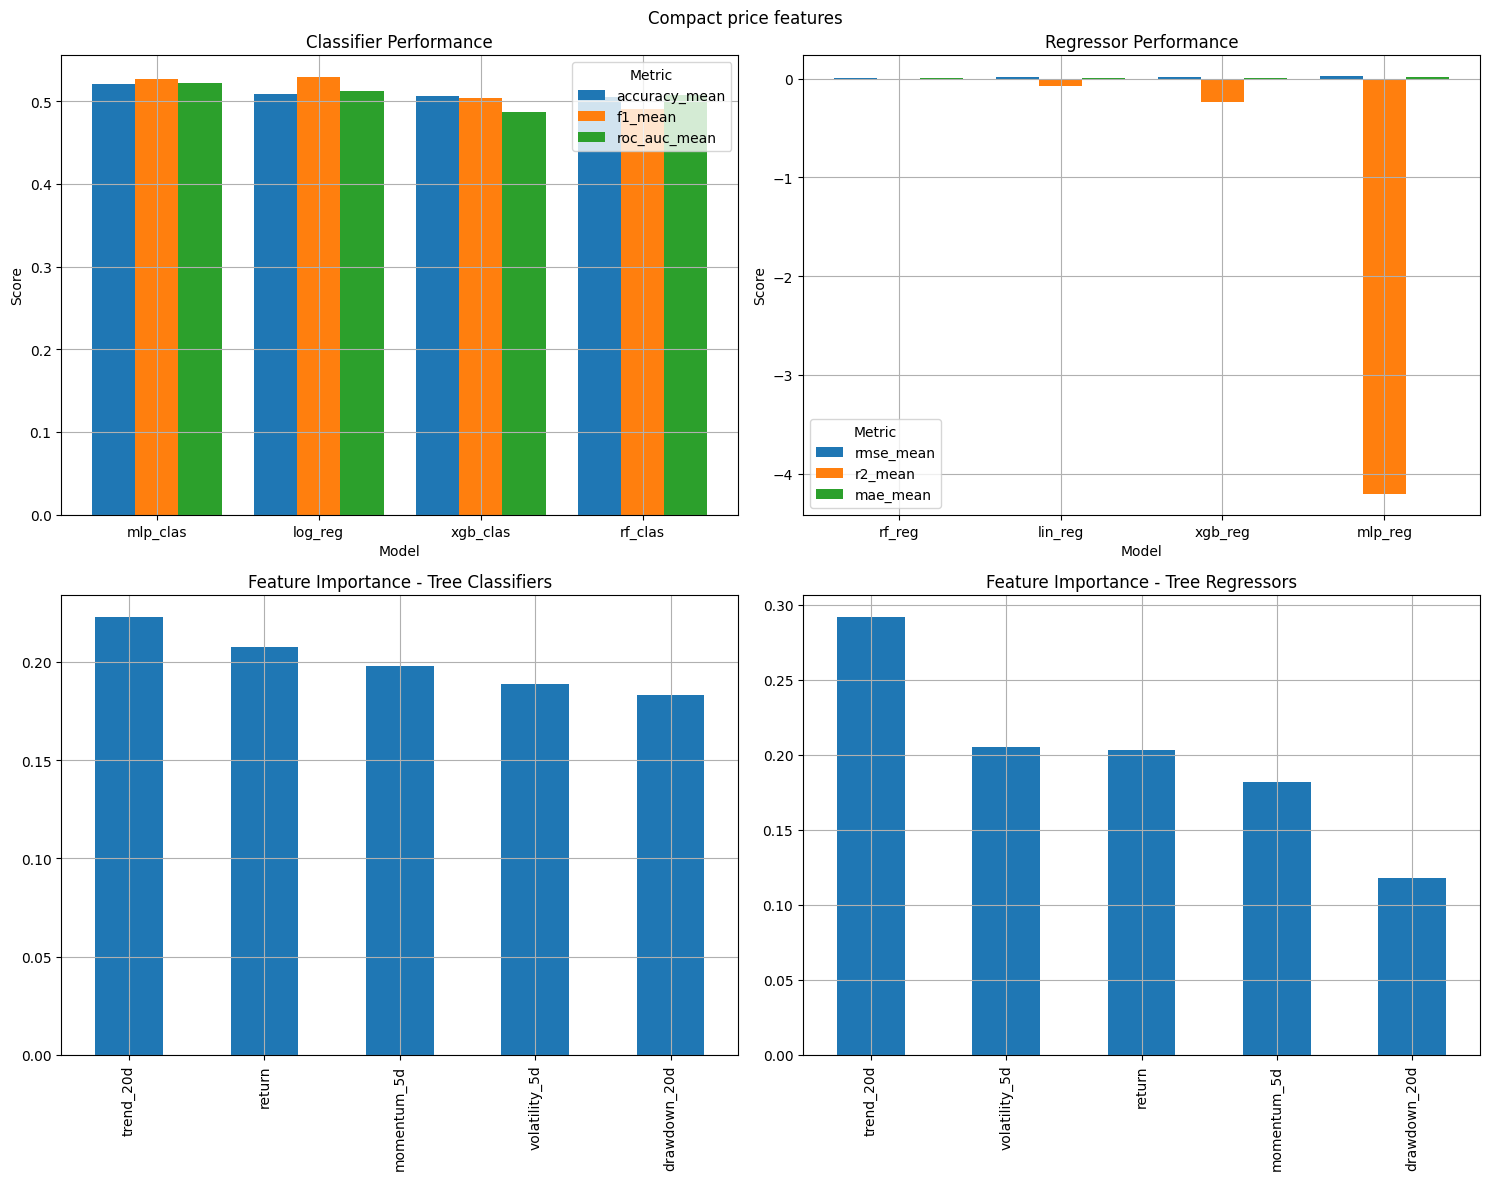

In [18]:
price_results = plot_model_results(price_features, "Compact price features")


### Testing sentiment, tone and price features

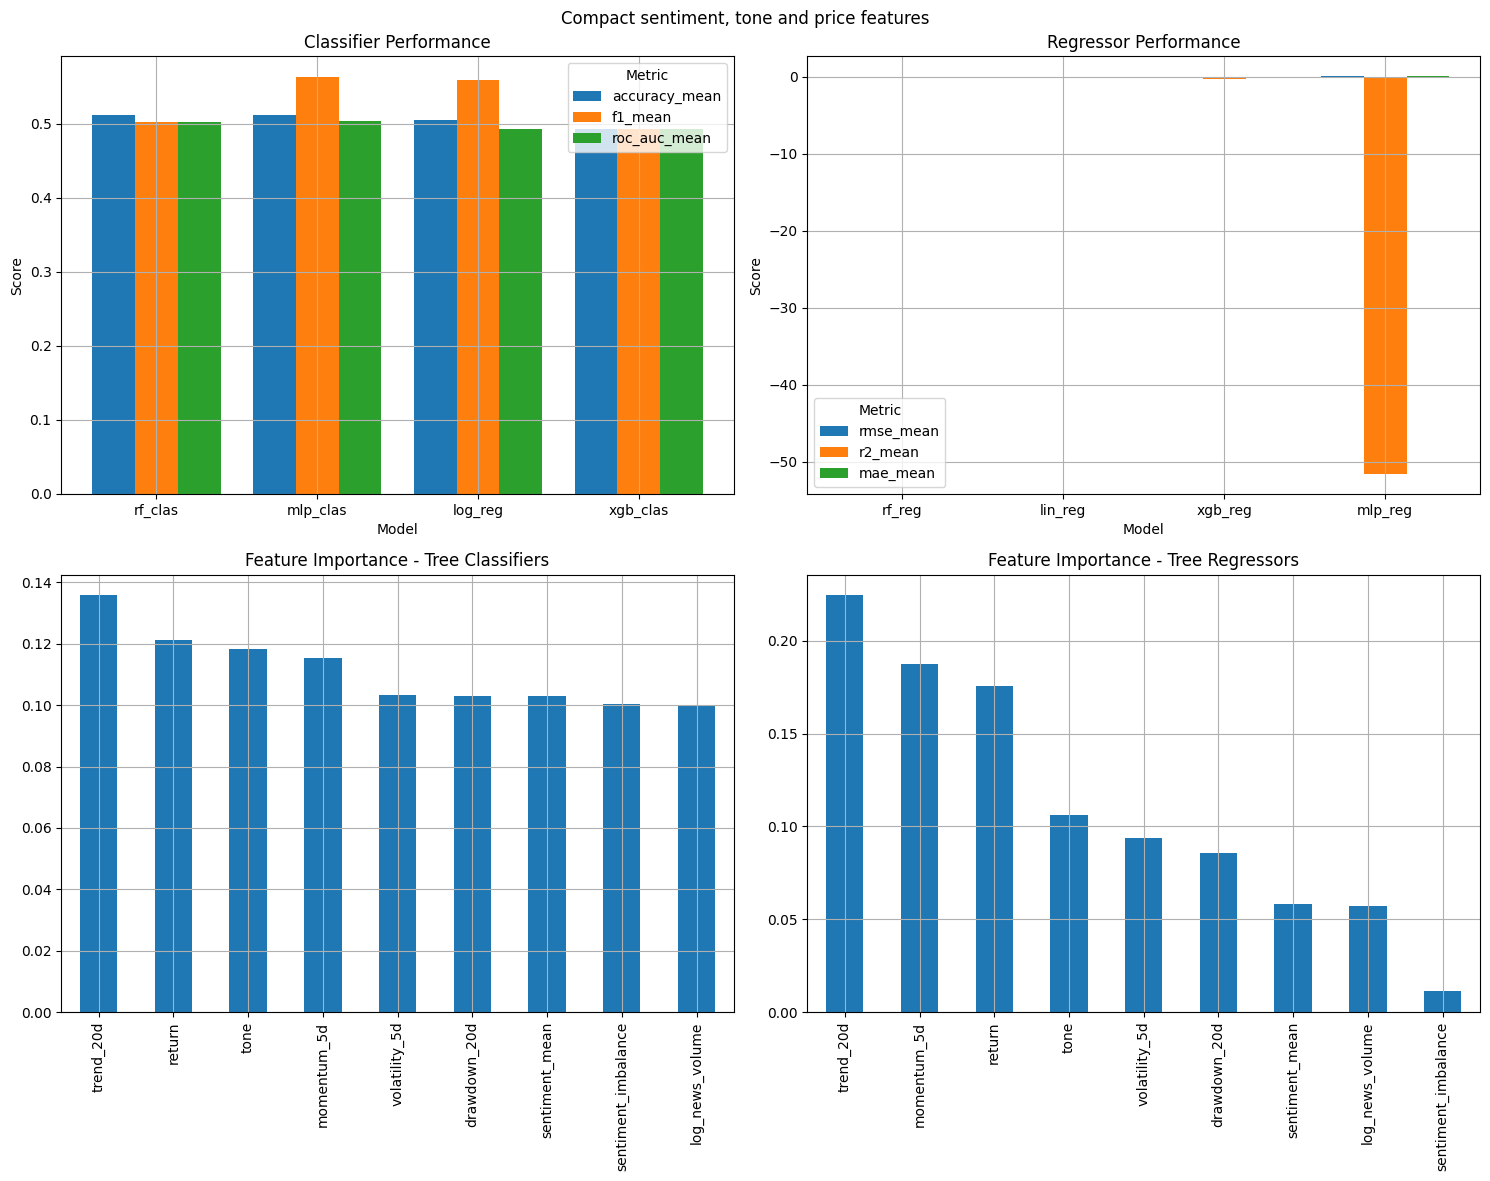

In [19]:
all_feature_results = plot_model_results(sentiment_features + gdelt_tone_features + price_features, "Compact sentiment, tone and price features")


## Removing features using Recursive Feature Elimination

In [20]:
def run_rfecv(model, X, y, scoring):
    selector = RFECV(
        estimator=model,
        step=1,
        cv=TimeSeriesSplit(n_splits=5),
        scoring=scoring,
        n_jobs=-1
    )
    selector.fit(X, y)
    return selector

def get_feature_importance(model, feature_names):
    if hasattr(model, "coef_"):
        imp = np.abs(model.coef_).flatten()
    elif hasattr(model, "feature_importances_"):
        imp = model.feature_importances_
    else:
        raise ValueError("Model does not expose feature importance")

    return pd.Series(imp, index=feature_names)

### Testing only sentiment related features

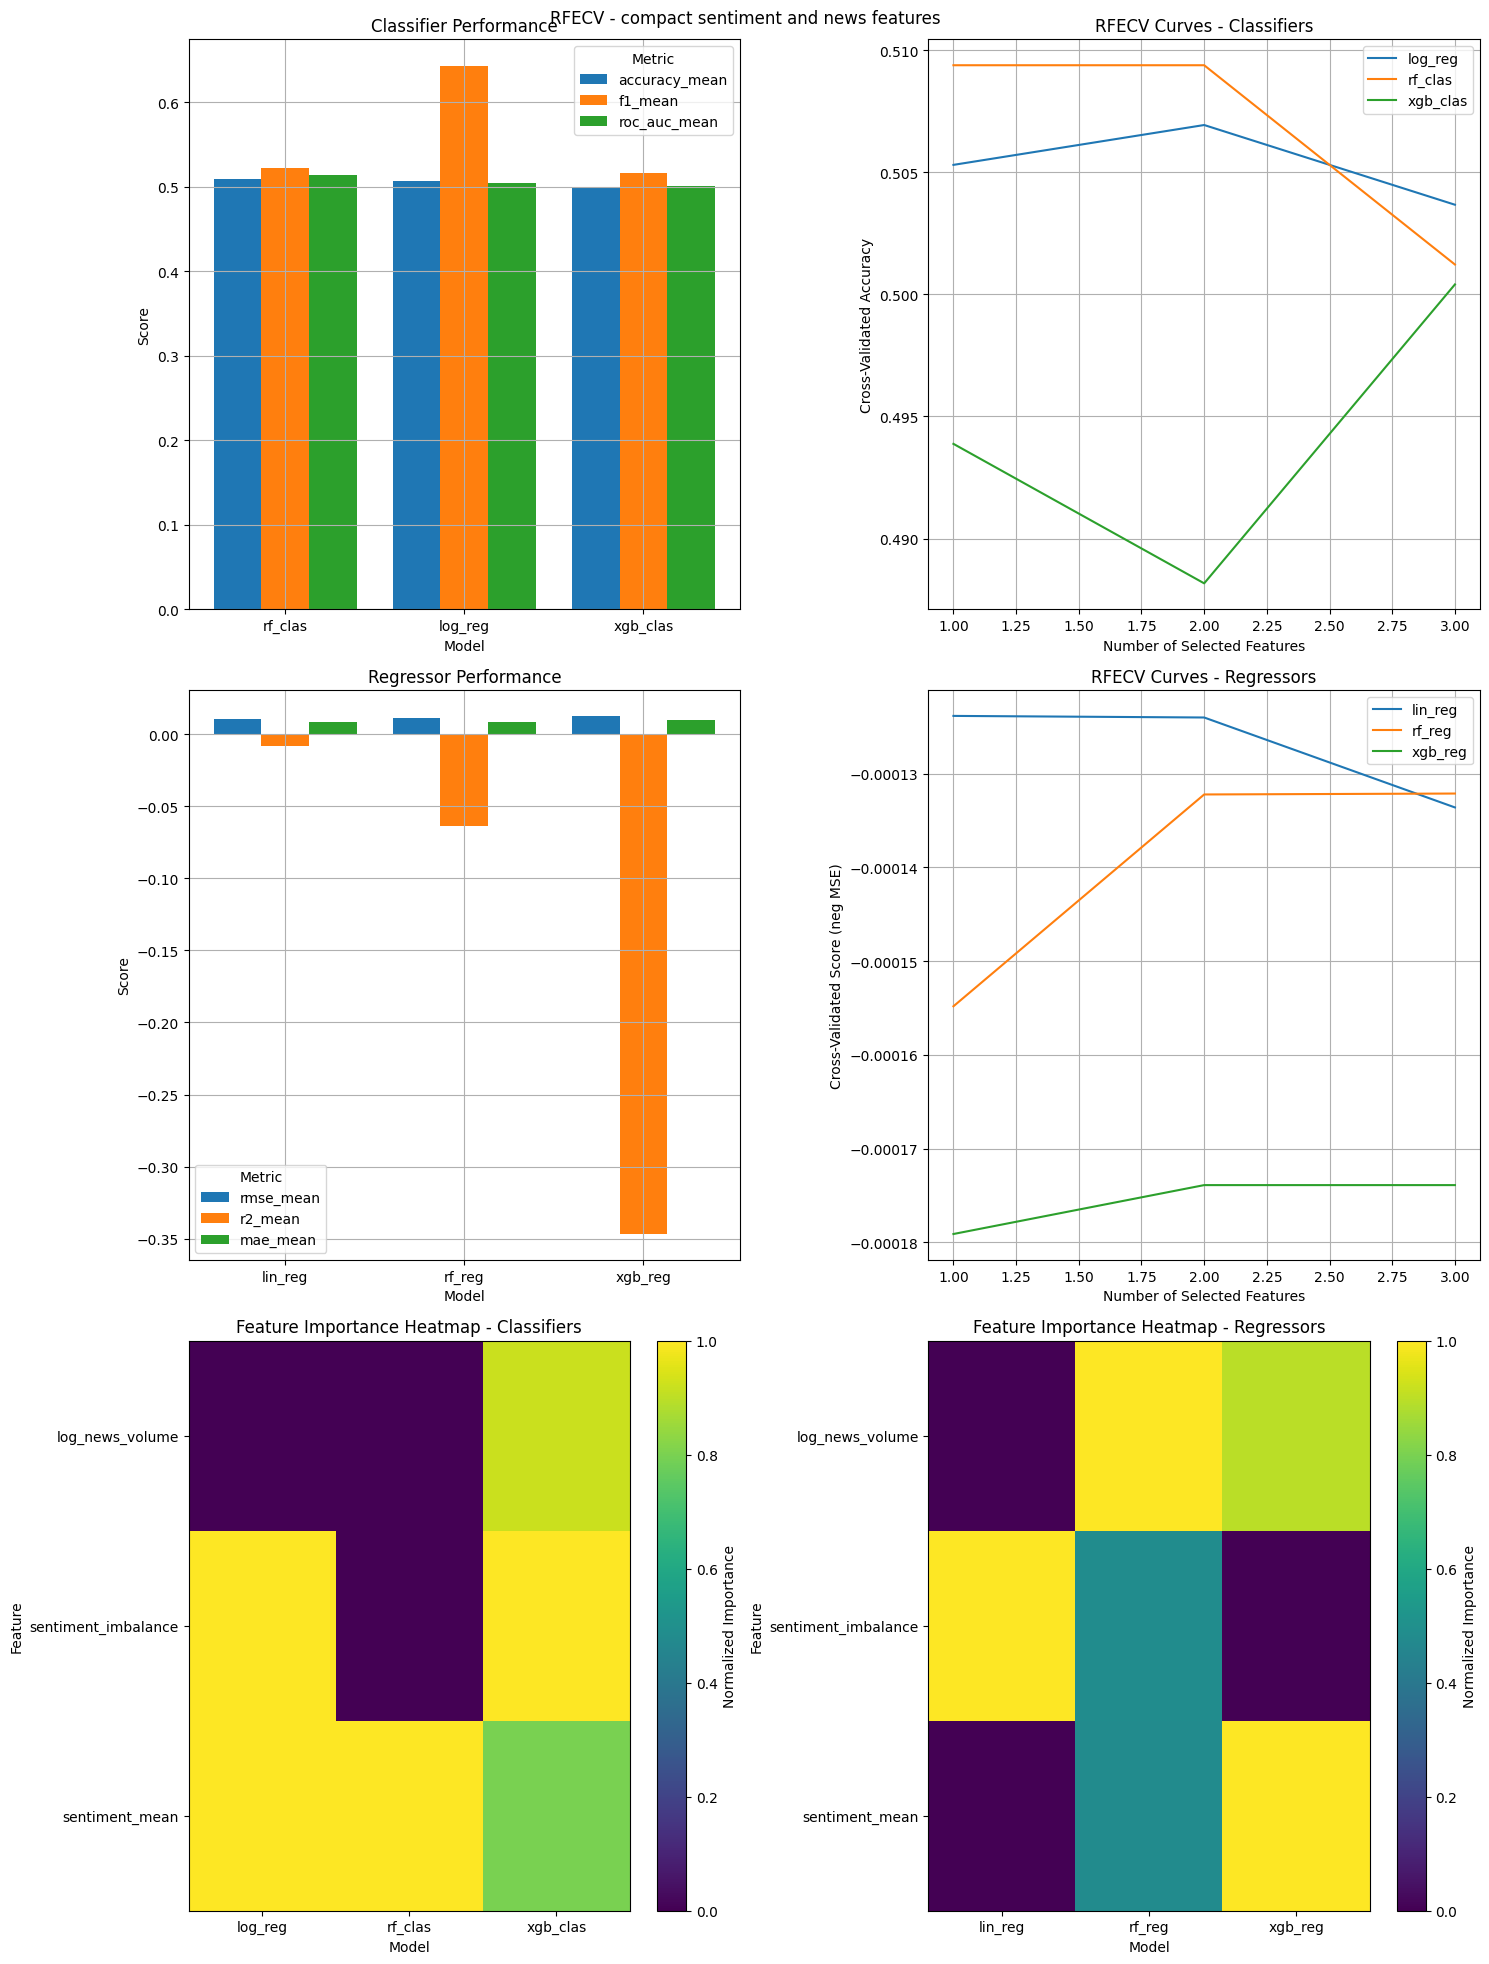

In [21]:
sentiment_rfecv_results = plot_rfecv_results(sentiment_features, "RFECV - compact sentiment and news features")


### Testing only price related features

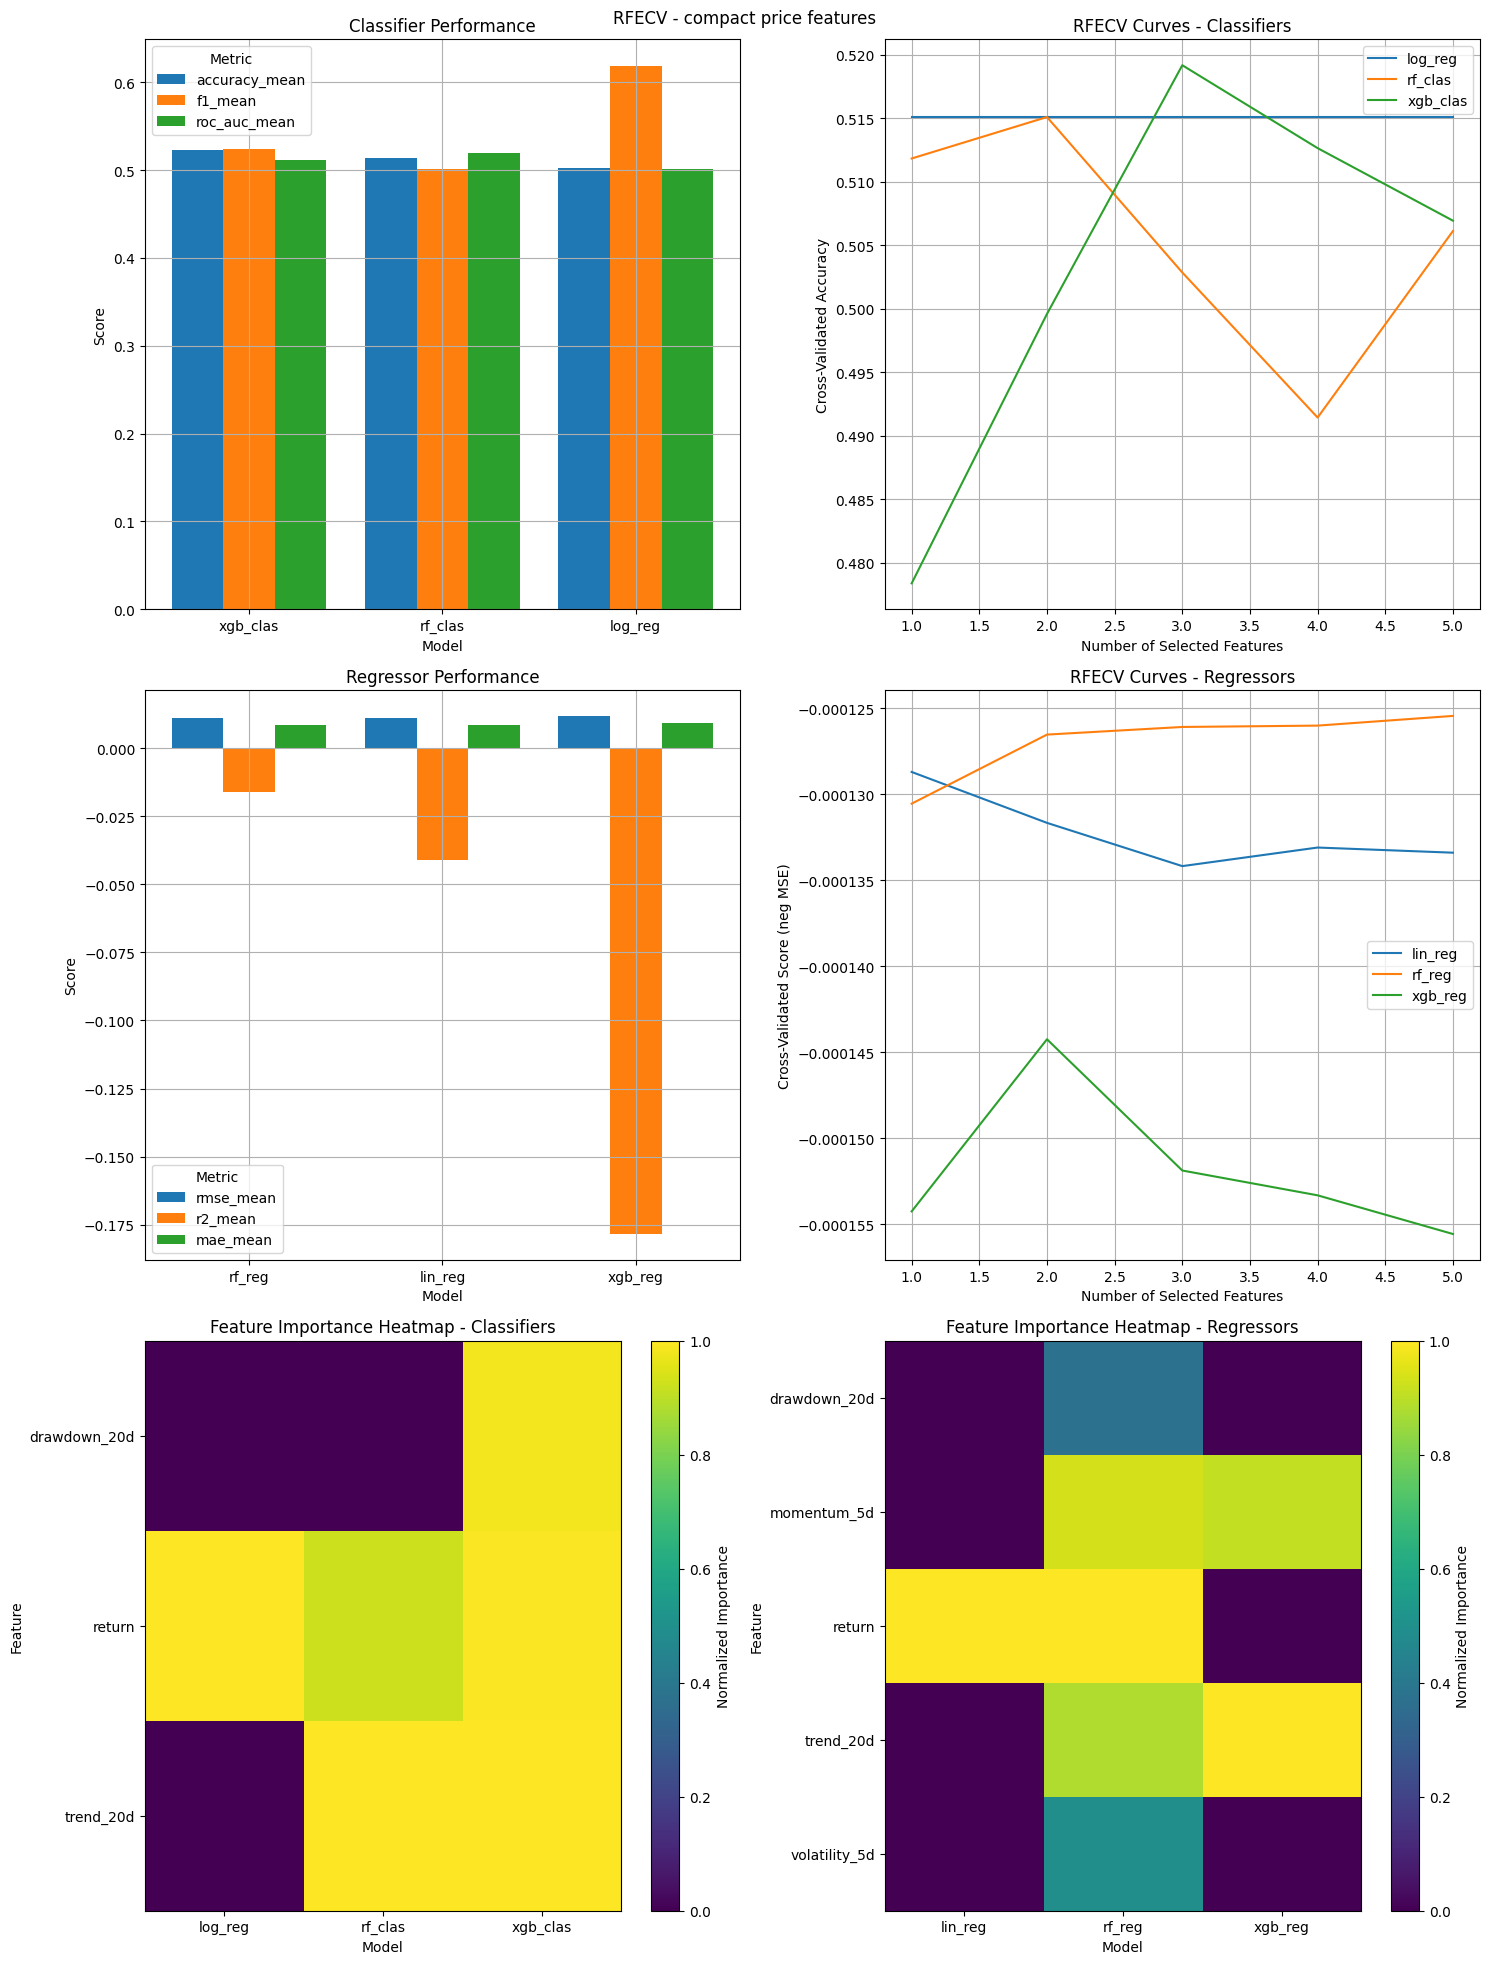

In [22]:
price_rfecv_results = plot_rfecv_results(price_features, "RFECV - compact price features")


### Testing sentiment, tone and price features

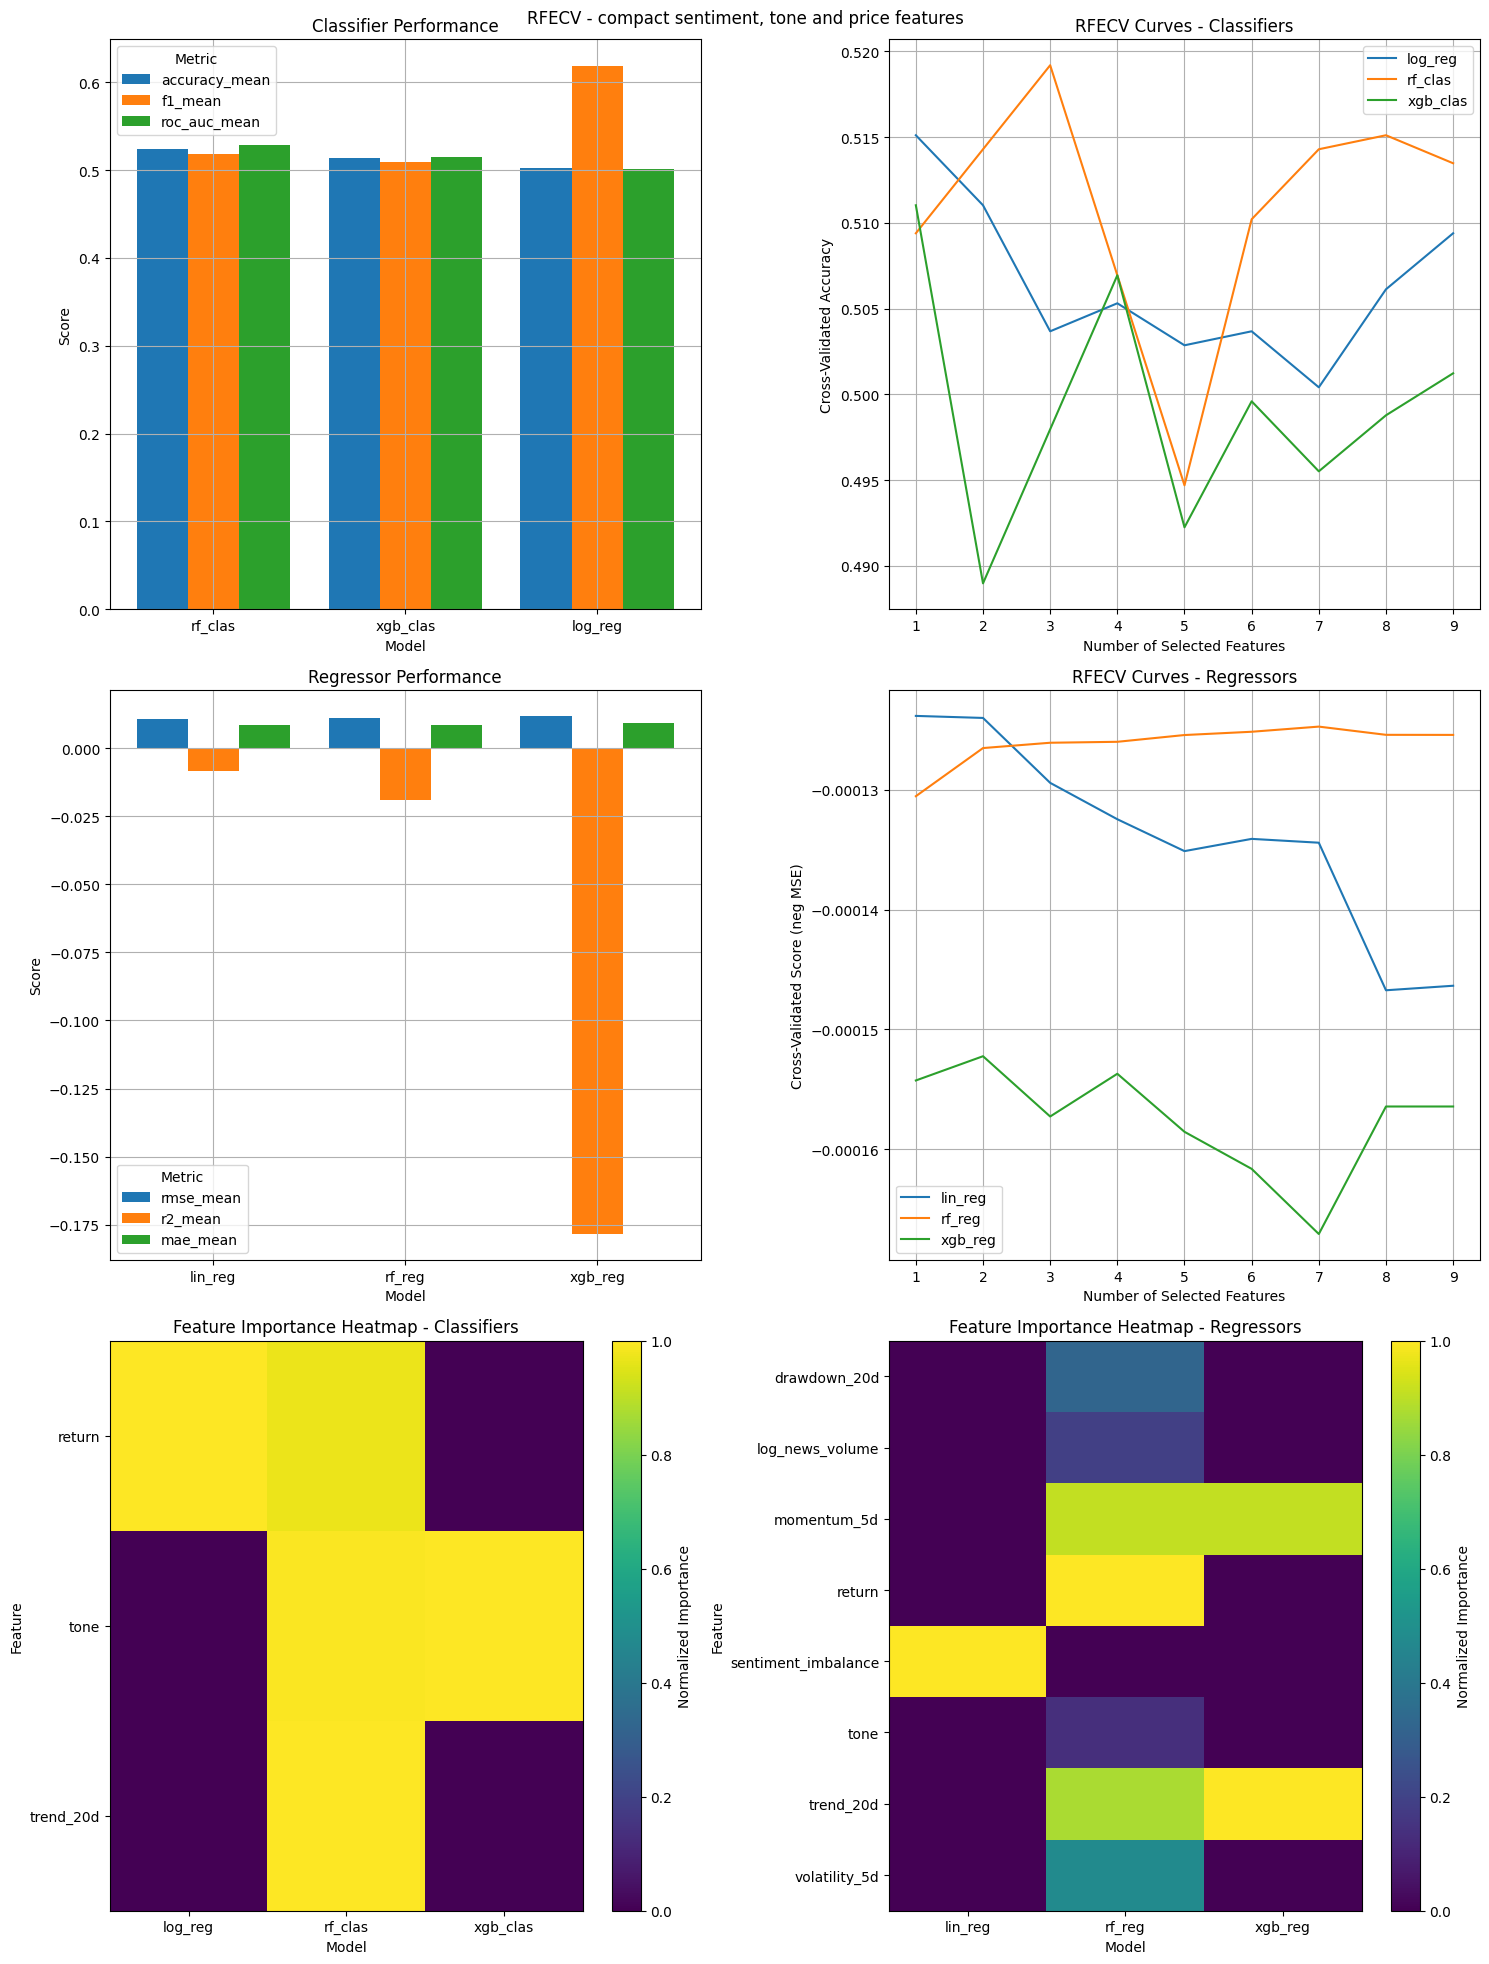

In [23]:
all_feature_rfecv_results = plot_rfecv_results(sentiment_features + price_features + gdelt_tone_features, "RFECV - compact sentiment, tone and price features")
